In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import finufft

In [18]:
# ---== Global Variables ==--- #
num_threads = 1

In [19]:
# ---== wave vector generation ==--- #

# We always assume the domain is [0, 1]^2

def generate_k_vectors_radial(K, num_per_dim=100):
    """
    Generate wavevectors with |k| < kmax
    on a uniform 2D grid using fftfreq
    """
    max_threshhold = 1.2*K**2
    min_threshhold = np.pi**2

    kx = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim) * 2 * np.pi
    ky = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim) * 2 * np.pi
    kx, ky = np.meshgrid(kx, ky, indexing='ij')
    k_flat = np.stack((kx.ravel(), ky.ravel()), axis=0)
    
    # Apply radial cutoff
    mag_k = np.sum(k_flat*k_flat, axis=0)
    mask = (mag_k > min_threshhold) & (mag_k < max_threshhold)
    return k_flat[:, mask]  # shape: (2, nk)

def generate_k_vectors(K):
    """
    Generate wavevectors with max|k| < kmax
    on a uniform 2D grid using fftfreq
    """
    max_threshhold = K
    min_threshhold = np.pi

    num_per_dim = int(max_threshhold/np.pi)

    kx = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim) * 2 * np.pi
    ky = np.fft.fftfreq(num_per_dim, d=1.0/num_per_dim) * 2 * np.pi
    kx, ky = np.meshgrid(kx, ky, indexing='ij')
    k_flat = np.stack((kx.ravel(), ky.ravel()), axis=0)
    
    # Apply cutoff
    max_k = np.max(np.abs(k_flat), axis=0)
    mask = (max_k > min_threshhold) & (max_k <= max_threshhold)
    return k_flat[:, mask]  # shape: (2, nk)


In [20]:
# ---== inital point pattern generation ==--- #

# Important: the domain is always [0, 1]^2

def random_point_pattern(N):
    return np.random.uniform(0, 1, size=(N, 2)) # shape : (rN, 2)

# ------
# the following methods generate approximately N points and exactly N points if N = k^2, for some k

def uniform_point_pattern(N):
    rN = round(np.sqrt(N))
    space = np.linspace(0.01, .99, rN)
    return np.array(np.meshgrid(space, space)).reshape(2, -1).T # shape : (rN, 2)

def perturbed_point_pattern(N, eps=0.01):
    uniform = uniform_point_pattern(N)
    rN = uniform.shape[0]
    pert_x = eps*np.random.uniform(-1, 1, size=(rN,))
    pert_y = eps*np.random.uniform(-1, 1, size=(rN,))
    uniform[:, 0] += pert_x
    uniform[:, 1] += pert_y
    return uniform  # shape : (rN, 2)

In [21]:
def compute_rho(k, r):
    N = r.shape[0]
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    c = np.ones(N, dtype=np.complex128)
    return finufft.nufft2d3(rx, ry, c, k[0, :], k[1, :], eps=1e-12, isign=+1, nthreads=num_threads) # (M,)

# for optimization purposes
def compute_S_rho(rho, N):
    return np.abs(rho)**2 / N

def compute_S(k, r):
    N = r.shape[0]
    return compute_S_rho(compute_rho(k, r), N)

def compute_bump(x, K_cutoff):
    A = 0.5                  # Height of the hill
    x0 = 0.9                 # Center of the hill before cutoff
    sigma = 0.1              # Width of the hill
    bump = 1 + A * np.exp(-((x - x0)**2) / (2 * sigma**2))
    #bump = np.where(x < K_cutoff, bump, 0.0)
    return bump

def compute_S0(k, D, H, alpha, K_cutoff):
    k_magnitude = np.linalg.norm(k, axis=0)  # (M,)
    S0 = np.where(k_magnitude < K_cutoff, D * (1 - H) * (k_magnitude**alpha) + H, 1.0)
    return S0 * compute_bump(k_magnitude/K_cutoff, K_cutoff)

def objective_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r, 1.0)
    S_kr = compute_S(k, r)
    return np.sum((S_kr - S0_k)**2)

def gradient_function(x, k, S0_k):
    N = x.shape[0] // 2
    r = x.reshape(N, 2)
    r = np.mod(r, 1.0)
    grad = np.zeros_like(r) # (N, 2)
    rho = compute_rho(k, r) # (M,)
    S_kr = compute_S_rho(rho, N) # (M,)
    factor = -4.j/N * ((S_kr - S0_k) * rho)
    C_hat_x = k[0, :] * factor # (M, )
    C_hat_y = k[1, :] * factor # (M, )
    rx = np.ascontiguousarray(r[:, 0])
    ry = np.ascontiguousarray(r[:, 1])
    grad[:, 0] = np.real(finufft.nufft2d3(k[0, :], k[1, :], C_hat_x, rx, ry, isign=-1, nthreads=num_threads))
    grad[:, 1] = np.real(finufft.nufft2d3(k[0, :], k[1, :], C_hat_y, rx, ry, isign=-1, nthreads=num_threads))
    return grad.flatten()

In [22]:
# ---== Visualization ==--- #

def plot_wave_vectors(k):
    plt.figure(figsize=(6, 6))
    plt.scatter(k[0, :], k[1, :], marker="x", color="green")
    plt.xlabel("$k_x$")
    plt.ylabel("$k_y$")
    plt.title("Wave vectors")
    plt.show()

def plot_particles(r, title):
    plt.figure(figsize=(6, 6))
    r = np.mod(r, 1.0) 
    plt.scatter(r[:, 0], r[:, 1], c="blue", s=20)
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()

def plot_structure_factor(r, k, K_cutoff, S0_k, title):
    S_kr = compute_S(k, r)
    print(S_kr.shape)
    k_magnitude = np.linalg.norm(k, axis=0)
    plt.figure(figsize=(8, 5))
    plt.scatter(k_magnitude/K_cutoff, S_kr, color="red", label="Computed S(k)")
    plt.scatter(k_magnitude/K_cutoff, S0_k, color="green", label="Computed S_0(k)", marker="x")
    plt.xlabel("|k|/K")
    plt.ylabel("S(k)")
    plt.title(title)
    plt.legend()
    plt.show()

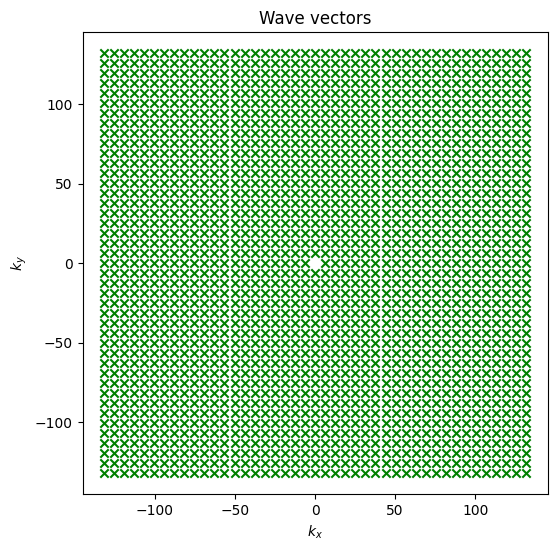

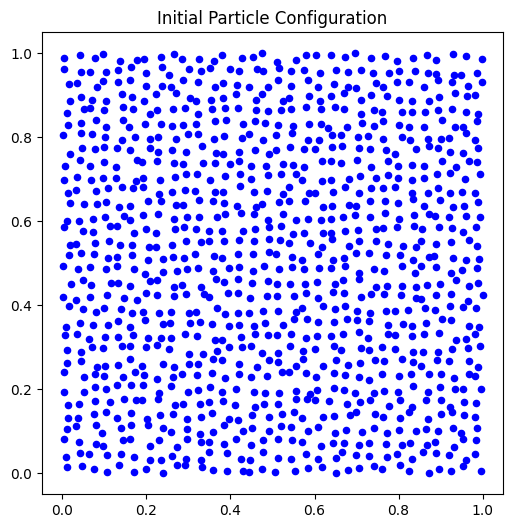

(1848,)


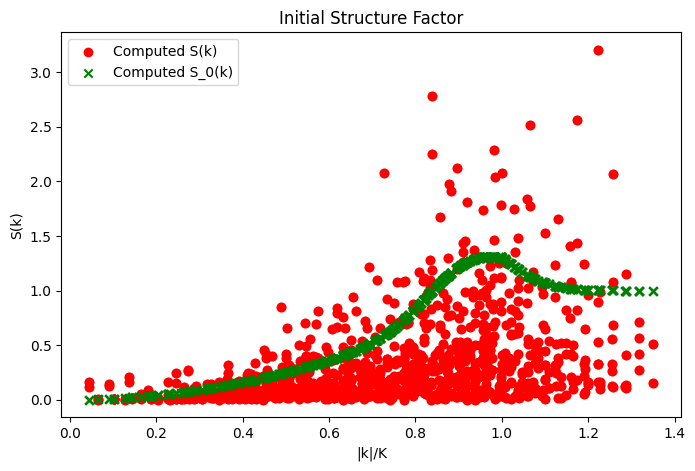

Value before optimizing:  672.6415582751861
         Current function value: 0.000057
         Iterations: 1000
         Function evaluations: 1004
         Gradient evaluations: 1004
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: 5.6577337585305024e-05
        x: [ 1.572e-02  3.355e-02 ...  9.859e-01  9.899e-01]
      nit: 1000
      jac: [-1.467e-02 -1.334e-02 ...  9.551e-03 -2.968e-02]
 hess_inv: [[ 5.986e-01 -1.542e-03 ...  2.261e-02 -1.536e-02]
            [-1.542e-03  6.307e-01 ...  4.487e-03 -6.100e-02]
            ...
            [ 2.261e-02  4.487e-03 ...  4.802e-01 -7.630e-03]
            [-1.536e-02 -6.100e-02 ... -7.630e-03  6.017e-01]]
     nfev: 1004
     njev: 1004
parameters saved to parms.csv
phi saved to point_patterns/pp.npy


c:\Users\eioer\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_minimize.py:733: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


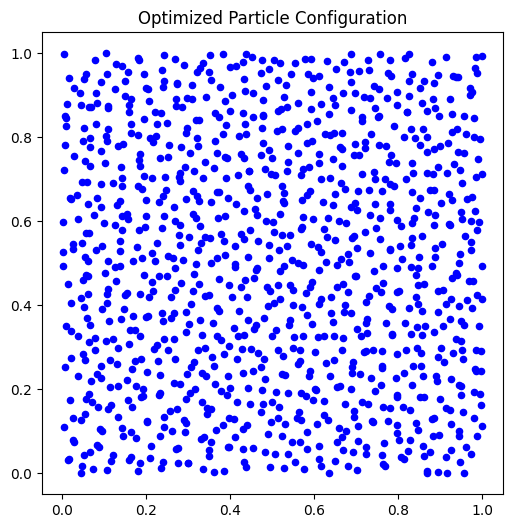

(1848,)


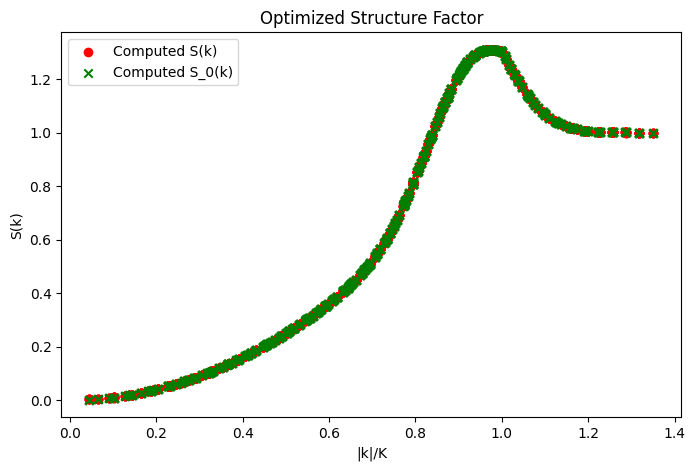

In [23]:
np.random.seed(0)  # For reproducibility

# ---== Parameters ==--- #

N = 1000
M = 100     

# Target structure factor parameters
H = 1e-4
alpha = 2.
K_cutoff = 44*np.pi
D = np.pow(K_cutoff, -alpha)

r_init = perturbed_point_pattern(N)
# since some point pattern generation algos dont give exactly N
N = r_init.shape[0] 

k = np.ascontiguousarray(generate_k_vectors(K_cutoff))
M = k.shape[1]

# Plot wave vectors used:
plot_wave_vectors(k)

# target structure factor precomputation
S0_k = compute_S0(k, D, H, alpha, K_cutoff)

# Plot before optimization
plot_particles(r_init, "Initial Particle Configuration")
plot_structure_factor(r_init, k, K_cutoff, S0_k, "Initial Structure Factor")

print("Value before optimizing: ", objective_function(r_init.flatten(), k, S0_k))

# ---== Run Optimization ==--- #
res = minimize(
    fun=objective_function,
    x0=r_init.flatten(),
    jac=gradient_function,
    args=(k, S0_k),
    method="BFGS",
    options={"disp": True, "maxiter": 1000},
    tol=1e-8
)

# ---== Postprocess ==--- #

r_opt = res.x.reshape(N, 2)  # Final particle positions
print(res)

# Save point pattern:
outfile = f"point_patterns/pp.npy"
np.save(outfile, r_opt)
with open("point_patterns/parms.csv", 'w') as f:
        f.write("N, M, D, H, K_cutoff, alpha\n")
        f.write(f"{N},{M},{D},{H},{K_cutoff},{alpha}\n")
print("parameters saved to parms.csv")
print(f"phi saved to {outfile}")

# Plot after optimization
plot_particles(r_opt, "Optimized Particle Configuration")
plot_structure_factor(r_opt, k, K_cutoff, S0_k, "Optimized Structure Factor")
